## In this notebook we will learn about Assumptions of Linear Regression

# 1) Assumption of Linearity 
- There should be linear relationship between independent variables and dependent variable

## To check this Assumption

### I - Scatter plot of  Independent variables with Dependent vairable
- This will give us an idea about relationship of independent and dependent variable

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100,1)

df = pd.DataFrame()

df["x1"] = x.reshape(100)
df["x2"] = y.reshape(100)
df["y"] = z.reshape(100)
df.head()

,x1,x2,y
0,-0.321064,1.416948,4.684270
1,3.861533,-2.177182,20.253174
2,-1.210140,1.714129,7.631271
3,1.682667,2.941793,15.336982
4,0.248679,1.398226,4.089395


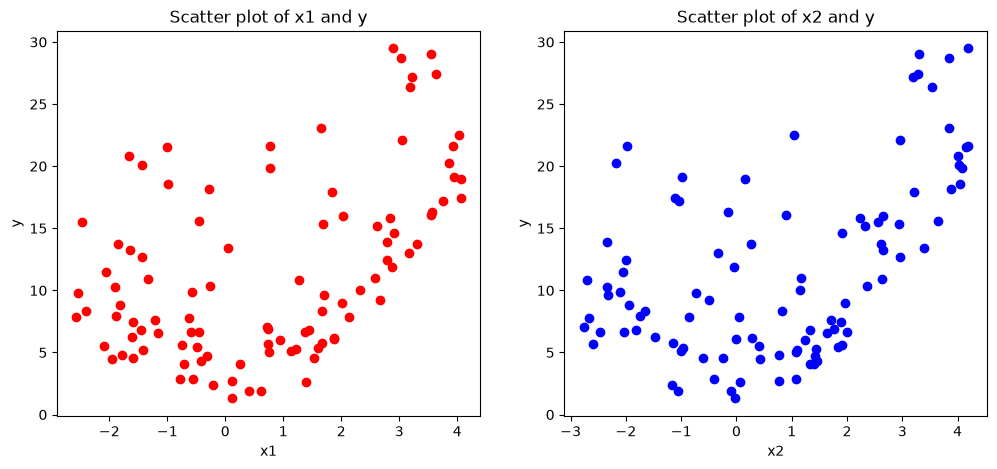

In [2]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

# Plot x1 and y
ax1.scatter(df["x1"], df["y"], color="red")
ax1.set_title("Scatter plot of x1 and y")
ax1.set_xlabel("x1")
ax1.set_ylabel("y")

# plot x2 and y
ax2.scatter(df["x2"], df["y"], color="blue")
ax2.set_title("Scatter plot of x2 and y")
ax2.set_xlabel("x2")
ax2.set_ylabel("y")

plt.show()

## II - Residual Plot 
- If our Residual plot is scattered Randomly then Assumption of Linearity is not violated means our data is Linear and if our Residual plot follows a pattern it means our data is not linear

Text(0, 0.5, 'Residuals')

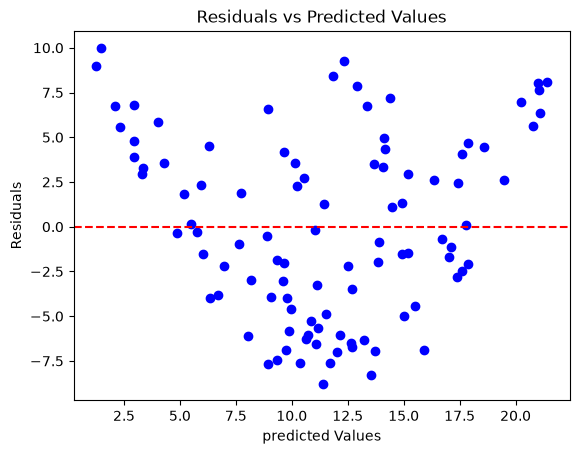

In [3]:
from sklearn.linear_model import LinearRegression

X = df[["x1", "x2"]]
y = df["y"]

model = LinearRegression()
model.fit(X,y)

y_pred = model.predict(X)
residuals = y - y_pred

plt.scatter(y_pred, residuals, color="blue")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("predicted Values")
plt.ylabel("Residuals")

### III - Adding polynomial Term to my model and compare the model fit with the original model 
- if performance increase after adding Polynomial terms it means Assumption is violated

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Fit Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_pred)

# Fit a Polynomial model
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_pred = poly_model.predict(X_test_poly)

poly_r2 = r2_score(y_test, poly_pred)

# Compare model performance
print("Linear Model")
print(f"R-Squared: {linear_r2:.4f}")

print("\nPolynomial model")
print(f"R-Squared: {poly_r2:.4f}")

Linear Model
R-Squared: 0.5854

Polynomial model
R-Squared: 0.9741


## Steps Taken when Assumption fails

### Step - I Applying Transformation
- In this example we use Sqaure root transformation but instead of Square root we can also use Box-Cox and Yeo-johnson
- We can also just use Polynomial Regression and can use non-parameteric methods

In [5]:
np.random.seed(42)
x = 10* np.random.rand(100,1)
y = x**2 + 5 + np.random.normal(0,5,(100,1))
y = np.abs(y) # Ensure y is positive 

# Applying Square-root transformation to y
y_sqrt = np.sqrt(y)

# Fit the linear regression models for the original and transformed data 
linear_org = LinearRegression()
linear_org.fit(x,y)

linear_trans = LinearRegression()
linear_trans.fit(x,y_sqrt)

# Prediction
y_pred_org = linear_org.predict(x)
y_pred_trans = linear_trans.predict(x)

# r2 Score
r2_original = r2_score(y,y_pred_org)
r2_transformed = r2_score(y_sqrt,y_pred_trans)

# Compare before and after transformation 
print("Original Linear model")
print(f"R-Squared: {r2_original:.4f}")

print("\nTransformed Linear model")
print(f"R-Squared: {r2_transformed:.4f}")

Original Linear model
R-Squared: 0.9008

Transformed Linear model
R-Squared: 0.9291


# 2) Normality of Residuals
- The error terms(Residuals) are assumed to follow a normal distribution 

## To check this Assumption

## Step - I ) Histogram and QQ Plot of Residuals

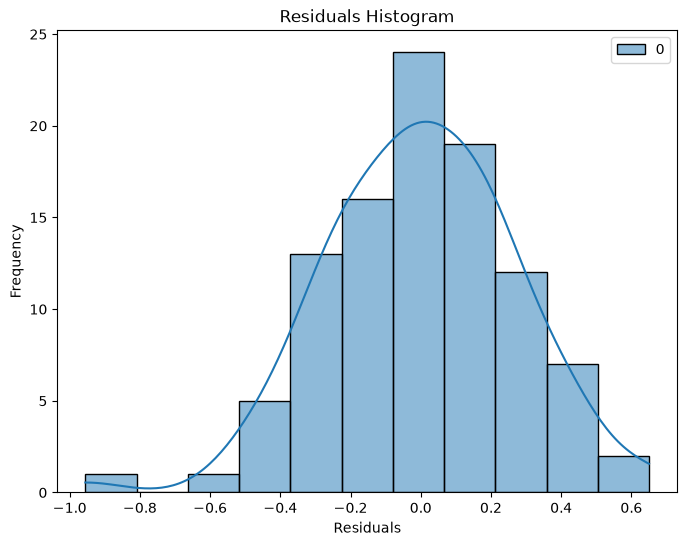

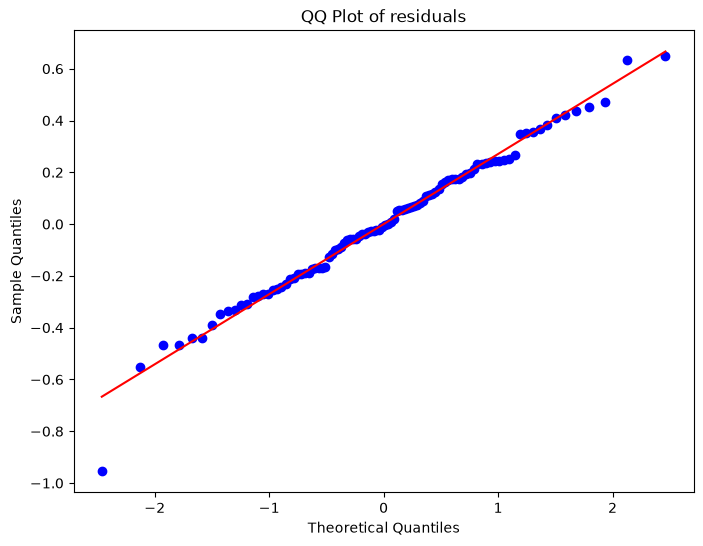

In [6]:
import seaborn as sns
from scipy import stats

x = np.random.rand(100,1)
y = 3*x + np.random.normal(0,0.3,(100,1))

model = LinearRegression()
model.fit(x,y)
y_pred = model.predict(x)

# Calculate the residuals 
residuals = y - y_pred

# Histogram
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residuals Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


# QQ Plot
plt.figure(figsize=(8,6))
stats.probplot(residuals.flatten(), plot=plt)
plt.title("QQ Plot of residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

## Step-II) Omnibus-Test
- Its null hypothesis states that residuals are normally distributed and the Alternate hypothesis says that the residuals are not normally distributed

In [7]:
x = np.random.rand(100,1)
y = 3*x + np.random.normal(0,0.3,(100,1))

model = LinearRegression()
model.fit(x,y)
y_pred = model.predict(x)

# Calculate the residuals 
residuals = y - y_pred

# Calculate skewness, kurtosis, Omnibus test statistic and p-value
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)
omnibus_stat, omnibus_p_value = stats.normaltest(residuals)


print(f"Skewness: {skewness[0]:.4f}")
print(f"Kurtosis: {kurtosis[0]:.4f}")
print(f"Omnibus Test Statistic: {omnibus_stat[0]:.4f}")
print(f"Omnibus Test P-value: {omnibus_p_value[0]:.4f}")

Skewness: 0.3321
Kurtosis: -0.0813
Omnibus Test Statistic: 2.0138
Omnibus Test P-value: 0.3653


# 3) Homoscedasticity
- Variance of Residuals should be constant across all predicted values

Text(0, 0.5, 'y2')

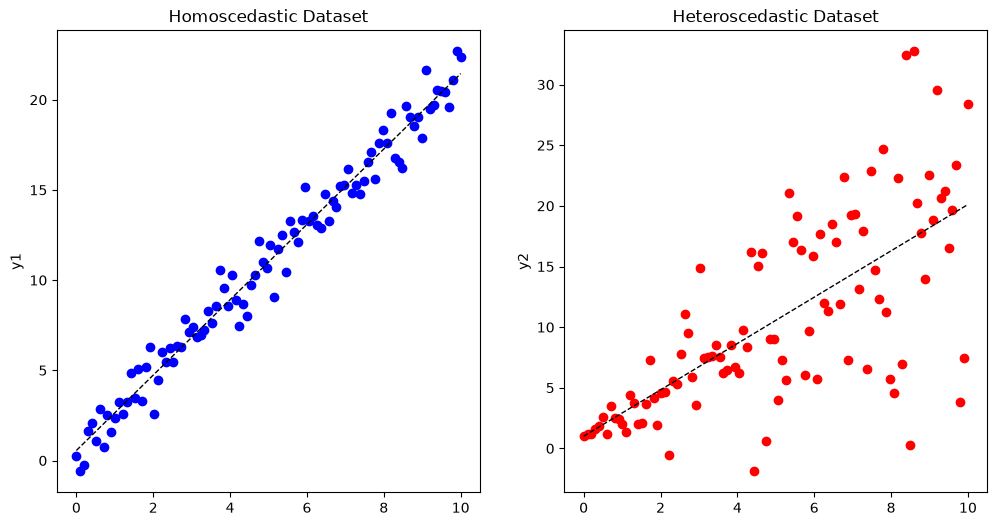

In [8]:
x = np.linspace(0,10,100)

# homoscedastic Dataset
y1 = 2 * x + 1 + np.random.normal(0,1,len(x))

# Heteroscedastic dataset
y2 = 2 * x + 1 + np.random.normal(0,x,len(x))

# fit the linear models
coeffs1 = np.polyfit(x,y1,1)
y1_pred = np.polyval(coeffs1,x)
residuals1 = y1 - y1_pred

coeffs2 = np.polyfit(x,y2,1)
y2_pred = np.polyval(coeffs2,x)
residuals2 = y2 - y2_pred

# Plot the residuals and dataset
fig, axes = plt.subplots(1,2, figsize=(12,6), sharex=True)

axes[0].scatter(x,y1,color="blue")
axes[0].plot(x,y1_pred, color="black",linestyle="--", lw=1)
axes[0].set_title("Homoscedastic Dataset")
axes[0].set_ylabel("y1")

axes[1].scatter(x,y2,color="red")
axes[1].plot(x,y2_pred, color="black",linestyle="--", lw=1)
axes[1].set_title("Heteroscedastic Dataset")
axes[1].set_ylabel("y2")

# Multicollinearity
- when two or more independent variables in a Multiple Regression model are highly correlated

## How to Detect Multicollinearity 

## Correlation
- when correlation between two independent variables is less than -0.8 and greater than 0.8 

In [9]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv')

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


<Axes: >

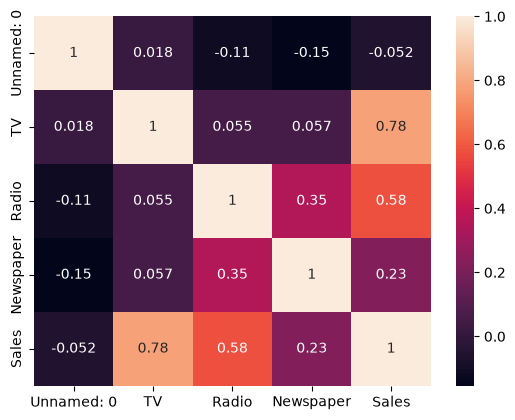

In [10]:
sns.heatmap(df.corr(), annot=True)

## VIF(Variance inflation factor)
- when vif is greater than 5 or 10 it means there is multicollinearity

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(3):
    vif.append(variance_inflation_factor(df.iloc[:,1:4],i))

In [12]:
pd.DataFrame({"Vif":vif}, index=df.columns[1:4]).T

,TV,Radio,Newspaper
Vif,2.486772,3.285462,3.055245


## Condition Number
- greater than 30 means there is multicollinearity in the data

In [13]:
from sklearn.preprocessing import StandardScaler

scaled_df = StandardScaler().fit_transform(df)

condition_number = np.linalg.cond(scaled_df)
print("Condition Number: ",condition_number)

Condition Number:  6.2761458462009765


## Why Multicollinearity is bad in inference
- inflated Standard Error
- unstable and unreliable coefficients

In [14]:
arr = np.array([[1,1,1,1,1,1,1,1,1,1],[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],[1.2, 2.1, 3.1, 4.1, 5.0, 6.0, 7.0, 8.0, 9.1, 10.2]]).T
arr   # this is our designed matrix and it also has multicollinearity 

array([[ 1. ,  1. ,  1.2],
       [ 1. ,  2. ,  2.1],
       [ 1. ,  3. ,  3.1],
       [ 1. ,  4. ,  4.1],
       [ 1. ,  5. ,  5. ],
       [ 1. ,  6. ,  6. ],
       [ 1. ,  7. ,  7. ],
       [ 1. ,  8. ,  8. ],
       [ 1. ,  9. ,  9.1],
       [ 1. , 10. , 10.2]])

In [18]:
arr_normal = np.array([[1,1,1,1,1,1,1,1,1,1],[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],[2.4, 0.7, 4.3, 3.5, 1.6, 5.1, 6.9, 7.5, 8.1, 9.8]]).T
arr_normal   # without multicollinearity

array([[ 1. ,  1. ,  2.4],
       [ 1. ,  2. ,  0.7],
       [ 1. ,  3. ,  4.3],
       [ 1. ,  4. ,  3.5],
       [ 1. ,  5. ,  1.6],
       [ 1. ,  6. ,  5.1],
       [ 1. ,  7. ,  6.9],
       [ 1. ,  8. ,  7.5],
       [ 1. ,  9. ,  8.1],
       [ 1. , 10. ,  9.8]])

In [15]:
np.linalg.inv(np.dot(arr.T,arr))# diagonal values are our estimates without multiply by standard deviation and square root look how inflated they are 

array([[  0.67713004,   1.89686099,  -1.97309417],
       [  1.89686099,  18.3309417 , -18.40807175],
       [ -1.97309417, -18.40807175,  18.49775785]])

In [19]:
np.linalg.inv(np.dot(arr_normal.T,arr_normal))   # diagonal values are at normal scale

array([[ 0.46684896, -0.06359872, -0.00341803],
       [-0.06359872,  0.06375331, -0.05752395],
       [-0.00341803, -0.05752395,  0.06408812]])

### Now unstable and unreliable estimates
- we will see if slightly change my one data point how it will affect data with multicollinearity and data without multicollinearity

In [24]:
# data with multicollinearity
arr = np.array([[1,1,1,1,1,1,1,1,1,1],[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],[1.2, 2.1, 3.1, 4.1, 5.0, 6.0, 7.0, 8.0, 9.1, 10.2]]).T
arr1 = np.array([[1,1,1,1,1,1,1,1,1,1],[1.1, 2, 3, 4, 5, 6, 7, 8, 9, 10],[1.2, 2.1, 3.1, 4.1, 5.0, 6.0, 7.0, 8.0, 9.1, 10.2]]).T

print("Diagonal values of data with mutlicollinearity\n: ",np.linalg.inv(np.dot(arr.T,arr)))

print("\nDiagonal values of data with multicollinearity with changes\n: ",np.linalg.inv(np.dot(arr1.T,arr)))

Diagonal values of data with mutlicollinearity
:  [[  0.67713004   1.89686099  -1.97309417]
 [  1.89686099  18.3309417  -18.40807175]
 [ -1.97309417 -18.40807175  18.49775785]]

Diagonal values of data with multicollinearity with changes
:  [[  0.62905003   2.33083535  -2.39640732]
 [  1.43222394  22.52479612 -22.49889795]
 [ -1.50650209 -22.6195724   22.60579678]]


In [28]:
# data without multicollinearity

arr_normal = np.array([[1,1,1,1,1,1,1,1,1,1],[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],[2.4, 0.7, 4.3, 3.5, 1.6, 5.1, 6.9, 7.5, 8.1, 9.8]]).T
arr_normal1 = np.array([[1,1,1,1,1,1,1,1,1,1],[1.1, 2, 3, 4, 5, 6, 7, 8, 9, 10],[2.4, 0.7, 4.3, 3.5, 1.6, 5.1, 6.9, 7.5, 8.1, 9.8]]).T

print("Diagonal values of data without mutlicollinearity\n: ",np.linalg.inv(np.dot(arr_normal.T,arr_normal)))

print("\nDiagonal values of data without multicollinearity with changes\n: ",np.linalg.inv(np.dot(arr_normal1.T,arr_normal1)))

Diagonal values of data without mutlicollinearity
:  [[ 0.46684896 -0.06359872 -0.00341803]
 [-0.06359872  0.06375331 -0.05752395]
 [-0.00341803 -0.05752395  0.06408812]]

Diagonal values of data without multicollinearity with changes
:  [[ 0.47202303 -0.06705466 -0.00051139]
 [-0.06705466  0.06552638 -0.05891698]
 [-0.00051139 -0.05891698  0.06515911]]


## How to Remove Multicollinearity
- Collect more data
- Remove one of the highly correlated variables
- combined correlated variables
- Partial Least Regression

### Partial Least Regression

In [44]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.cross_decomposition import PLSRegression

# Generate a synthetic dataset with multicollinearity
np.random.seed(42)
X,y = make_regression(n_samples=100, n_features=3, noise=0.5, random_state=42)
X[:, 1] = X[:,0] + 0.5 * np.random.normal(size=100)   # Introduce multicollinearity between columns 0 and 1

data = pd.DataFrame(X, columns=["X1","X2","X3"])
data["y"] = y

X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,0:3], data.iloc[0:,-1], test_size=0.2, random_state=42)

pls_model = PLSRegression(n_components=2)

pls_model.fit(X_train, y_train)

y_pred = pls_model.predict(X_test)

print("Mean Squared Error: ",mean_squared_error(y_test, y_pred))

Mean Squared Error:  7359.987203343638
